# Tasca S11.01. Visualització de Dades amb Python i Power BI
**Descripció**  
Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector
from mysql.connector import Error
import seaborn as sns
import plotly.express as px
from dotenv import load_dotenv
load_dotenv()
import os


## **Nivell 1**
### 1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.



In [ ]:

try:
    connection = mysql.connector.connect(host='localhost',
                                         database='sprint4_db',
                                         user='root',
                                         password=os.getenv('MYSQL_PASSWORD'))
                                        
    if connection.is_connected():
        print("Connected to MySQL Server version ", connection.database)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)


## Obtenim els noms de les taules i les posem en una llista
cursor.execute("SHOW TABLES;")
taules = cursor.fetchall()

## Fem diccionari de les taules de la BBDD
tables_df = {}

for x in taules:
    nom_taula= x[0]

    query = f"SELECT * FROM {nom_taula}"
    cursor.execute(query)

    data = cursor.fetchall()
    columnes=cursor.column_names 

    df = pd.DataFrame(data, columns=columnes)

    tables_df[nom_taula] = df

## Tanquem la connexió
cursor.close()
connection.close()
print("MySQL connection is closed")

## Convertim a DF cada taula del diccionari
for nom, df in tables_df.items():
        nom_taula = "df_"+ nom

        globals()[nom_taula] = df 
        df_trobat=globals()[nom_taula]
        print("Les taules de la BBDD de dades són les següents:") 
        print(f"\n{nom_taula}") 
        display(globals()[nom_taula].head(5))


Connected to MySQL Server version  sprint4_db
You're connected to database:  ('sprint4_db',)
MySQL connection is closed
Les taules de la BBDD de dades són les següents:

df_companies


,id_company,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings


Les taules de la BBDD de dades són les següents:

df_credit_cards


,id_credit_card,user_id,iban,pan,pin,cvv,track1,track2,expiring_date
0,CcS-4857,276,XX4857591835292505850771,2314242385113924,1819,467,%B2314242385113924^LWCBUDLWCBUD^22060000000000...,%B2314242385113924=2410101518363164?,2025-09-27
1,CcS-4858,277,XX8581768137002436094025,6582720299715533,3964,817,%B6582720299715533^TIQMVITIQMVI^24040000000000...,%B6582720299715533=2411101104546272?,2028-12-28
2,CcS-4859,278,XX7826930491423553609370,8861684536289642,4983,277,%B8861684536289642^COFBGDCOFBGD^28020000000000...,%B8861684536289642=2502101761665371?,2026-11-26
3,CcS-4860,279,XX5559590368835304645299,2481155515498459,6876,661,%B2481155515498459^TIUJTUTIUJTU^31040000000000...,%B2481155515498459=2602101514414395?,2027-07-27
4,CcS-4861,280,XX2035182877195191627307,1308930301149557,5710,398,%B1308930301149557^HPOBNZHPOBNZ^33010000000000...,%B1308930301149557=2805101751305028?,2026-04-25


Les taules de la BBDD de dades són les següents:

df_estat_targetes


...

,id_transaction,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.5972,12.22180
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,72,2115,53.5489,-113.50300
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.2084,5.69081


Les taules de la BBDD de dades són les següents:

df_transactions_products


,id_transaction,id_products
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1


Les taules de la BBDD de dades són les següents:

df_users


,id_user,name,surname,phone,email,birth_date,country,city,postal_code,address
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,1984-04-30,United States,San Jose,95101,P.O. Box 773
2,100,Melodie,Mclean,1-677-221-7152,risus.varius@google.ca,1989-09-15,United States,San Jose,95101,Ap #644-8492 Sagittis St.
3,1000,Amkjrv,Qbulrxbp,+48-258-9936,amkjrv.qbulrxbp@example.com,1970-05-17,Germany,Stuttgart,70173,215 Qbulrxbp St
4,1001,Nfvrlb,Oydaiwbg,+94-121-2522,nfvrlb.oydaiwbg@example.com,1994-03-04,Germany,Cologne,50667,121 Oydaiwbg St


### **2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.**

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

Configuració Visual


In [71]:
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8, 5)

### Una variable numèrica.

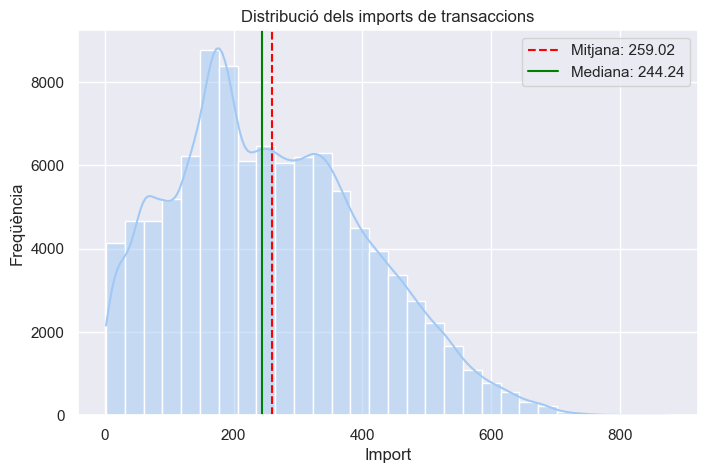

In [72]:

mean_val = df_transactions ["amount"].mean()
median_val = df_transactions["amount"].median()

plt.figure(figsize=(8,5))
sns.histplot(df_transactions["amount"], bins=30, kde=True)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mitjana: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
plt.title("Distribució dels imports de transaccions")
plt.xlabel("Import")
plt.ylabel("Freqüència")
plt.legend()
plt.show()


**Anàlisi i interpretació del gràfic**

Es fa un Histograma amb línia KDE combinat amb indicadors de tendència central (mitjana i mediana) de l'import de les transaccions que ens permeten veure on es concentra el gruix de la distribució.

S'observa assimetria a la dreta, indicant això que la gran majoria de les transaccions es concentren en valors entre els 100 i els 300 euros, mentre que hi ha una cua llarga cap a la dreta que indica l'existència de transaccions amb imports molt més altes, fins arribar a superar el 800 euros tot i que són molt menys freqüents.

### Dues variables numèriques

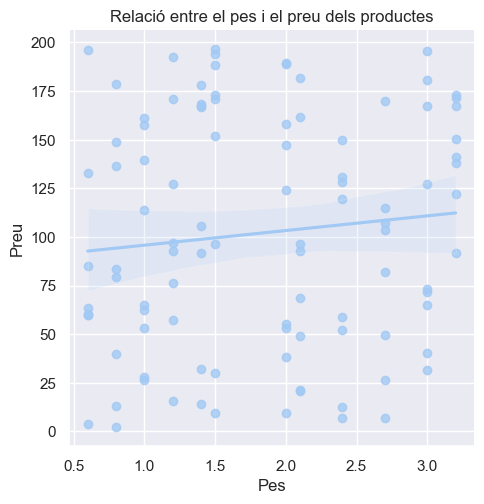

In [73]:
sns.lmplot(data=df_products, x="weight", y="price");
plt.title("Relació entre el pes i el preu dels productes")
plt.xlabel('Pes'); 
plt.ylabel('Preu');
plt.show()

**Anàlisi i interpretació del gràfic**

Fem un Gràfic de dispersió amb línia de regressió lineal.  Utilitzen les variables Pes a l'eix X i preu a l'eix Y. Observem que el gràfic mostra una correlació positiva molt feble entre el pes i el preu dels productes. La línia de regressió té un pendent lleugerament ascendent, el que suggereix que a mesura que el pes augmenta, el preu tendeix a ser marginalment més alt, encara que la dispersió dels punts indica que no hi ha una relació directa clara

### 1 varaible categórica

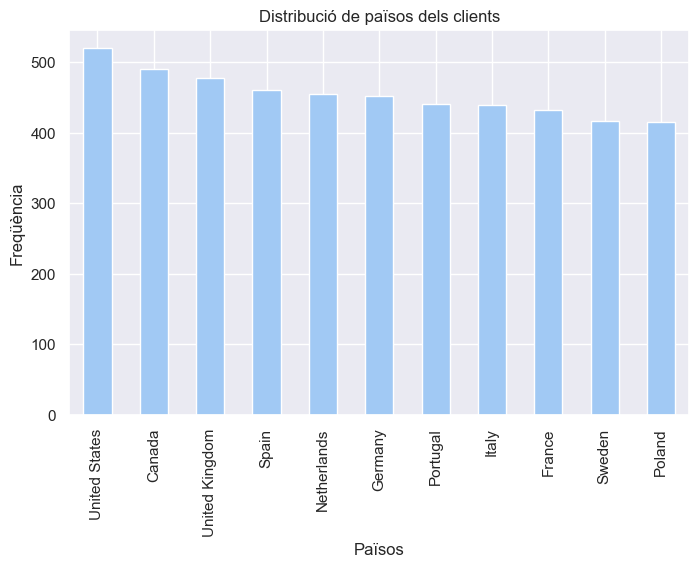

In [74]:
df_users["country"].value_counts().plot.bar()

plt.title("Distribució de països dels clients")
plt.ylabel("Freqüència")
plt.xlabel("Països")
plt.show()

**Anàlisi i interpretació del gràfic**

Fem un gràfic de barres on es compta el número de clients per pais. S'observa una distribució bastant equilibrada, on els Estats Units, el Canadà i el Regne Unit encapçalen la llista, però sense diferències abismals entre països, indicant una base d'usuaris diversificada geogràficament.


Fem un gràfic addicional que mostra el mateix, però en forma de treemap i usant la biblioteca Plotly

In [75]:
paisos = (df_users["country"].value_counts().reset_index())

paisos.columns = ["country", "num_usuaris"]


fig = px.treemap(
    paisos,
    path=["country"],
    values="num_usuaris",
    color="num_usuaris",
    title="Distribució d'usuaris per país"
)
fig.update_traces(textinfo="label+value+percent entry")
fig.show()

### Una variable categòrica i una numèrica.

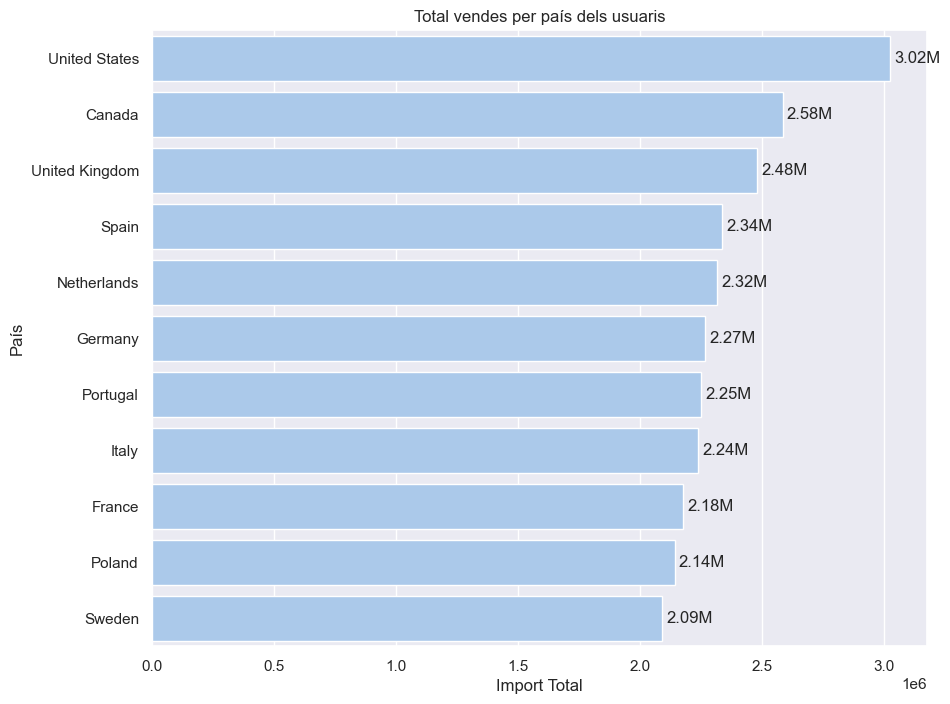

In [77]:

df_4 = pd.merge(df_transactions, df_users, left_on='user_id', right_on='id_user')
df_4 = df_4.groupby('country')['amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
ax=sns.barplot(data=df_4, x='amount', y='country', orient='h' )

plt.title('Total vendes per país dels usuaris')
ax.bar_label(ax.containers[0], labels=[f"{v/1_000_000:.2f}M" for v in ax.containers[0].datavalues], padding=3)
plt.xlabel('Import Total')
plt.ylabel('País')
plt.show()

**Anàlisi i interpretació del gràfic**

Fem gràfic de barres horitzontals on el que anlitzem és la despesa del clients per país, ordenada de major a menor. Durant el període temps analitzat, veiem que els Estats Units amb (3.02M) són els clients que compren més, seguit pel Canadà i el Regne Unit.

## Dues variables categòriques.

Creem una variable categórica "tipus_compra" que ens indicarà si els clients han comprat en empreses del seu país o no, i mirarem la feqüencia que els usuaris de cada país compren en pres del seu pais o de l'estranger

In [80]:

df_5 = df_transactions.merge(df_users, left_on='user_id', right_on='id_user').merge(df_companies, left_on='business_id', right_on='id_company', suffixes=('_user', '_comp'))

df_5['tipus_compra'] = np.where(df_5['country_user'] == df_5['country_comp'],'Local','Internacional') 

df_5 = pd.crosstab(df_5['country_user'], df_5['tipus_compra'])

## df_5.head()

In [81]:
fig = px.bar(df_5, barmode='stack', title="Compres Locals vs Internacionals per pais del client")
fig.update_layout(xaxis_title="",yaxis_title="Quantitat de transaccions")
fig.show()

**Anàlisi i interpretació del gràfic**

Fem un gràfic de barres apilades, on analitzem les variables categòriques: el país de l'usuari (country_user) i el tipus de compra (tipus_compra: Local o Internacional).  
Observem que laa gran majoria de les transaccions a tots els països són de tipus "Internacional". Les compres "Locals" tenen una presència menor i relativament constant en volum entre els diferents països, el que podria indicar un model de negoci fortament orientat a l'exportació





## Tres variables combinades

In [95]:
df_6 = df_transactions.merge(df_companies[["id_company", "country"]],left_on="business_id",right_on="id_company")

df_6["any"] = df_6["timestamp"].dt.year

df_6 = (
    df_6.groupby(["any", "country"])
      .agg(
          vendes=("amount", "sum"),
          import_mitja=("amount", "mean")
      )
      .reset_index()
)

##df_6.head()


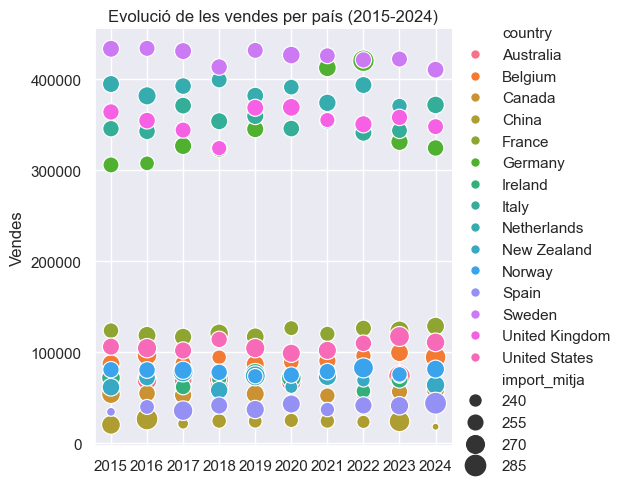

In [96]:
sns.relplot(data=df_6, x="any", y="vendes", hue="country", size="import_mitja", sizes=(25,250));

plt.xticks(range(int(df_6["any"].min()), int(df_6["any"].max()) + 1)) ## forcem a que es mostrin tots els anys en l'eix
plt.title('Evolució de les vendes per país (2015-2024)');
plt.xlabel('')
plt.ylabel('Vendes')
plt.show()


**Anàlisi i interpretació del gràfic**

Fem gràfic de dispersió amb bombolles on analitzem tres variables combinades: any (temps) a l'eix X, vendes (volum total) a l'eix Y, i import_mitjà de les transaccions (mida de la bombolla) pels països de les empreses.
Això pot veure veure l'evolució temporal i on es poden identificar els països amb més volum total (bombolles situades més amunt en l'eix Y) i comparar el seu comportament mitjà en preu (mida de la bombolla). La posició estable dels grups de països suggereix que no hi ha hagut variacions dràstiques en la tendència de vendes durant el període observat

## Pairplot

In [97]:
df_7 = df_transactions.merge(df_companies,left_on="business_id",right_on="id_company")

df_7 = (df_7.groupby("business_id")
      .agg(
          total_venut=("amount", "sum"),
          import_mitja=("amount", "mean"),
          num_transaccions=("id_transaction", "count")
      )
      .reset_index()
)
##df_7.head()

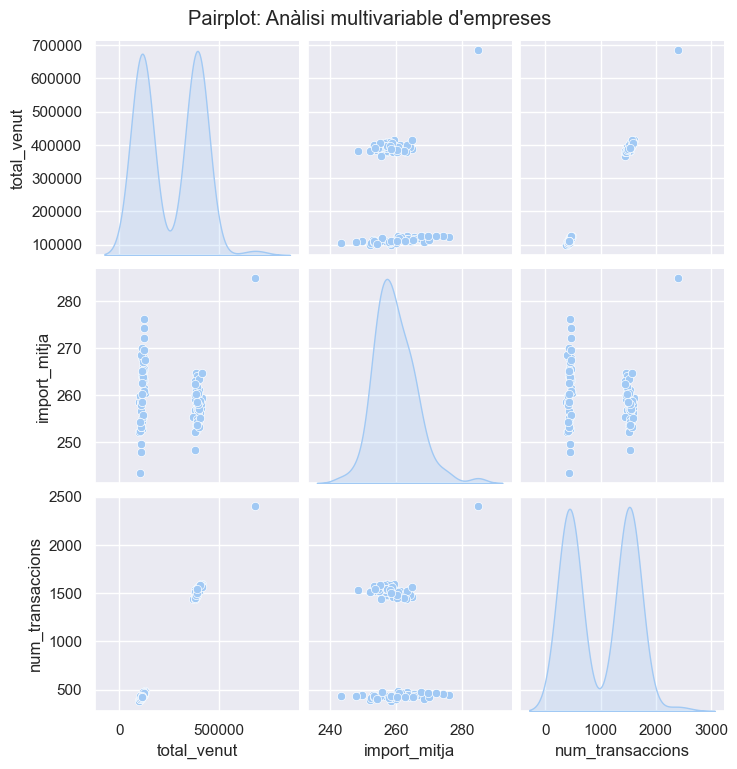

In [98]:
g=sns.pairplot(df_7[[ "total_venut","import_mitja","num_transaccions"]],diag_kind='kde' );
g.fig.suptitle("Pairplot: Anàlisi multivariable d'empreses", y=1.02);
plt.show()


**Anàlisi i interpretació del gràfic**

Fem un pairplot on analitzem tres variables numèriques calculades per cadascuna de les empreses de la base de dades: total_venut, import_mitja i num_transaccions. 

El que s'observa és: A la diagonal, veiem la distribució (KDE) de cada variable, on s'observen distribucions bimodals per al total_gastat i num_transaccions, indicant dos perfils d'empreses clarament diferenciats (probablement petites vs. grans).En els gràfics de dispersió (fora de la diagonal), es veu una relació lineal molt marcada entre total_gastat i num_transaccions, el que indica que el volum de vendes total, en bona lógica, ve molt determinat pel nombre de transaccions realitzades, més que per l'import mitjà per compra.


## **Nivell 2**

### 1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

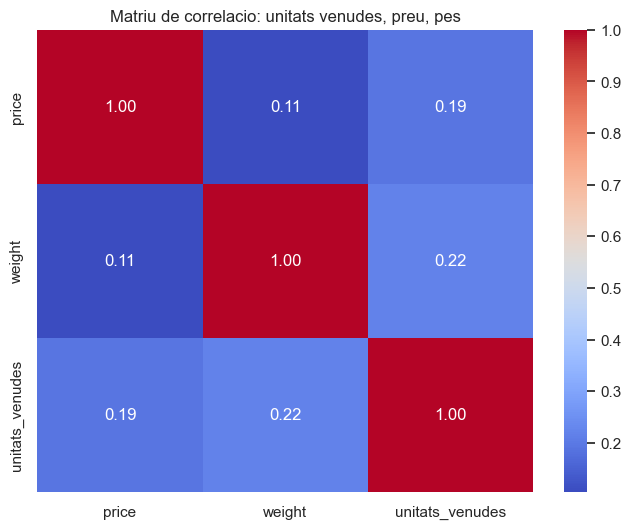

In [99]:
unitats = (
     df_transactions_products
    .groupby("id_products")
    .size()
    .reset_index(name="unitats_venudes")
)

df_corr = df_products.merge(unitats, left_on="product_id", right_on="id_products",how="left")
df_corr = df_corr[["price", "weight", "unitats_venudes"]]
corr = df_corr.corr()


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriu de correlacio: unitats venudes, preu, pes")
plt.show()

**Anàlisi i interpretació del gràfic**

Es mira la relació entre el preu, el pes i les unitats de producte venudes, amb els següents resultats:
Relació Preu - Pes (0.11): La correlació és molt baixa. Això indica que, el pes del producte no té cap influència significativa sobre el preu. És a dir, trobem tant productes lleugers cars com pesats barats (i viceversa).
Relació Preu - Unitats Venudes (0.19): També és una correlació molt baixa. És possible que el volum de vendes depengui més d'altres factors.
Relació Pes - Unitats Venudes (0.22): És la correlació més alta de la matriu, tot i que segueix sent un valor baix. No hi ha una evidència clara que els productes més pesats es venguin més que els més lleugers.


### 2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

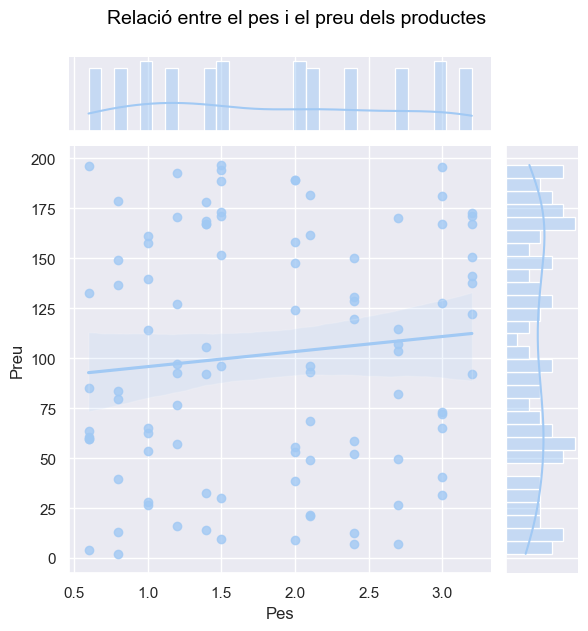

In [100]:
sns.jointplot(x="weight", y="price", data=df_products, kind="reg", marginal_kws={'bins': 30})
plt.suptitle("Relació entre el pes i el preu dels productes", fontsize=14,y=1.05,color="black")
plt.xlabel('Pes'); 
plt.ylabel('Preu');
plt.show()


**Anàlisi i interpretació del gràfic**


Hem usat les mateixes dues variables de l'exercici 1.2.2, el preu i el pes dels productes, i com havien comentat, que és el que es veu en l'scatter plot central, hi ha correlació positiva molt feble entre el pes i el preu dels productes, indicant que no hi ha una relació directa clara entre el pes i el preu dels productes.
Histograma superior (Pes): La distribució del pes és força uniforme. El pes dels 100 productes del catàleg es bastant uniforme entre 0,6 i 3 kilos
Histograma superior (Preu): . La distribució és bastant uniforme entre el preu de 2 i 200. Pot indicar això, que els preus no són fixats de forma contínua en funció del pes

**Anàlisi i interpretació del gràfic**


## **Nivell 3**
Recorda: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.



Carreguem les dades a Power BI amb el segünet codi (el password no s'ha posat, en executar a Power BI sí):

In [ ]:
import mysql.connector
from mysql.connector import Error
import pandas as pd

try:
    connection = mysql.connector.connect(host='localhost',
                                         database='sprint4_db',
                                         user='root',
                                         password='')
                                         
    if connection.is_connected():
        print("Connected to MySQL Server version ", connection.database)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)


## Obtenim els noms de les taules i els posem en una llista
cursor.execute("SHOW TABLES;")
taules = cursor.fetchall()

## Fem diccionari de les taules
tables_df = {}

for x in taules:
    nom_taula= x[0]

    query = f"SELECT * FROM {nom_taula}"
    cursor.execute(query)

    data = cursor.fetchall()
    columnes=cursor.column_names 

    df = pd.DataFrame(data, columns=columnes)

    tables_df[nom_taula] = df


cursor.close()
connection.close()


# Convertim a DF cada taula del diccionari
for nom, df in tables_df.items():
        nom_taula = "df_"+ nom

        globals()[nom_taula] = df 
        df_trobat=globals()[nom_taula]
       



Per a graficar les tres variables combinades i el Pairplot afegim a Power Bi dues taules addicionals amb les mètriques que usarem. 
Ho fem directament fent la consulta SQL per obtenir la taula i la convertim en DF que és el que es traspassa a Power BI.

In [ ]:
import mysql.connector
from mysql.connector import Error
import pandas as pd

try:
    connection = mysql.connector.connect(host='localhost',
                                         database='sprint4_db',
                                         user='root',
                                         password='')
                                         
    if connection.is_connected():
        print("Connected to MySQL Server version ", connection.database)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)

query = """
SELECT YEAR(t.timestamp) AS any, c.country, 
       SUM(t.amount) AS vendes, 
       AVG(t.amount) AS import_mitja
FROM transactions AS t
JOIN companies AS c ON t.business_id = c.id_company
GROUP BY any, c.country
"""
cursor.execute(query)

data = cursor.fetchall()  
columns = cursor.column_names

df_3var = pd.DataFrame(data, columns=columns)

#############################

query = """
SELECT 
    business_id, 
    SUM(amount) AS total_venut, 
    AVG(amount) AS import_mitja, 
    COUNT(id_transaction) AS num_transaccions
FROM transactions
GROUP BY business_id
"""

cursor.execute(query)

data = cursor.fetchall()  
columns = cursor.column_names

df_pairplot = pd.DataFrame(data, columns=columns)

cursor.close()
connection.close()
